In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Preparation:

In [47]:
data = pd.read_excel('heart_disease1.xlsx')

In [48]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


### 2.Exploratory Data Analysis (EDA)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [50]:
data.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [51]:
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

#### Yes we found null found null values in oldpeak column.. soo lets check data is equally distributed or not

<function matplotlib.pyplot.show(close=None, block=None)>

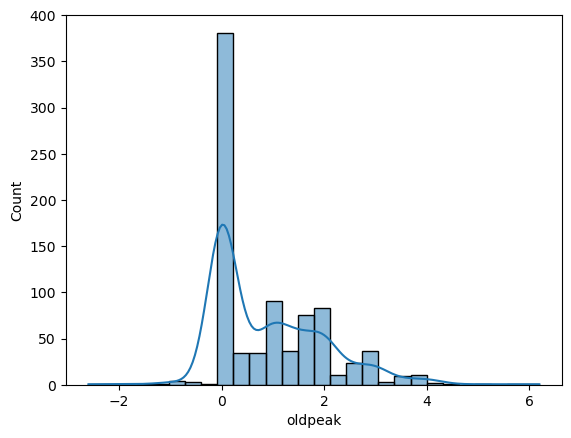

In [52]:
sns.histplot(data['oldpeak'],kde=True)
plt.show

#### According to above histogram we can see that data is not equally distributed soo we can not use mean value for nan replacement. we have to use medianfor nan replacement

In [53]:
data['oldpeak'].fillna(data['oldpeak'].median(), inplace=True)

/var/folders/c6/rh118pnd4z74yrqrmh0p58mc0000gn/T/ipykernel_29955/2117449708.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['oldpeak'].fillna(data['oldpeak'].median(), inplace=True)


In [54]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [55]:
data['fbs'] = data['fbs'].astype(int)

In [56]:
num_col = data.select_dtypes(include=['int64','float64'])
num_col

,age,trestbps,chol,fbs,thalch,oldpeak,num
0,63,145,233,1,150,2.3,0
1,41,135,203,0,132,0.0,0
2,57,140,192,0,148,0.4,0
3,52,118,186,0,190,0.0,0
4,57,110,201,0,126,1.5,0
...,...,...,...,...,...,...,...
903,53,125,0,0,120,1.5,4
904,62,166,170,0,120,3.0,4
905,56,170,0,0,123,2.5,4
906,56,144,208,1,105,0.5,4


### Visualization :

#### 1. Histogram :

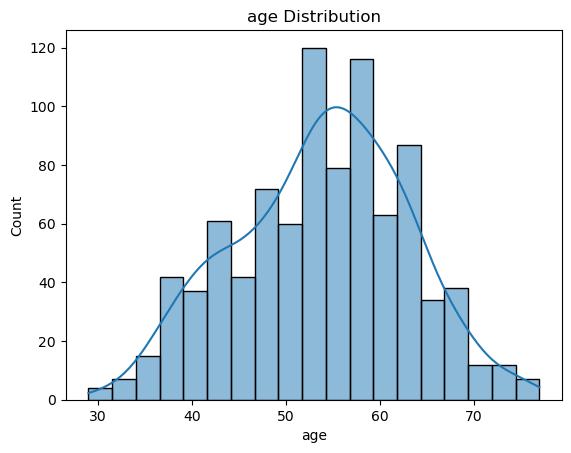

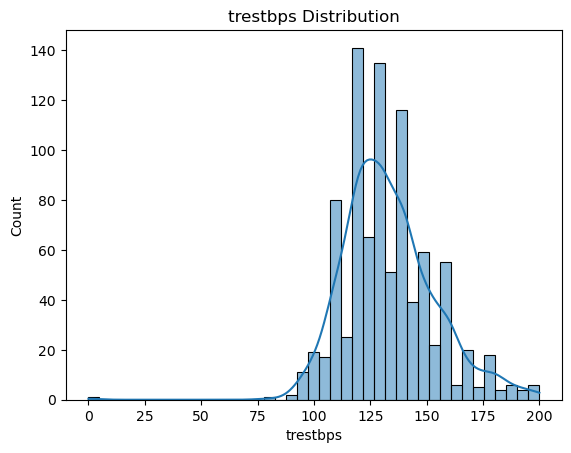

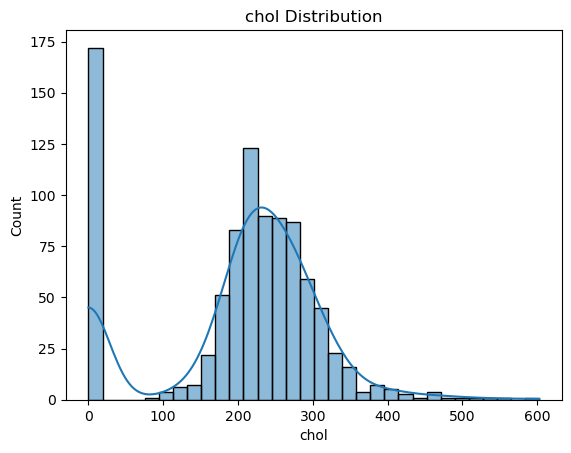

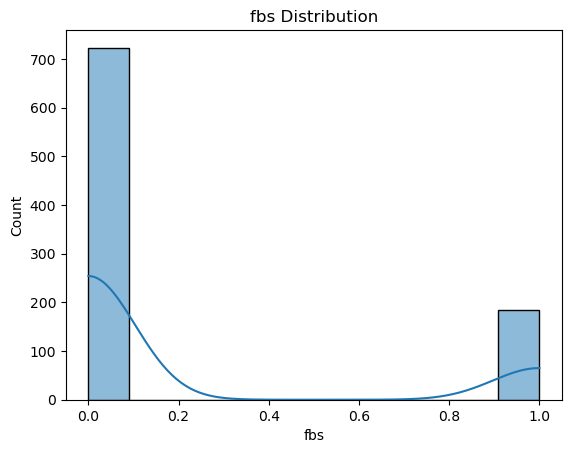

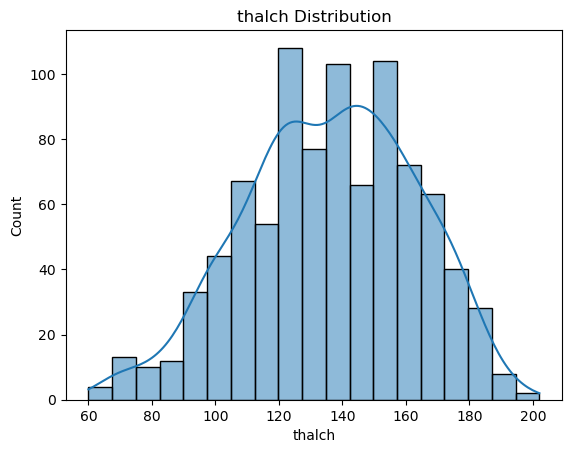

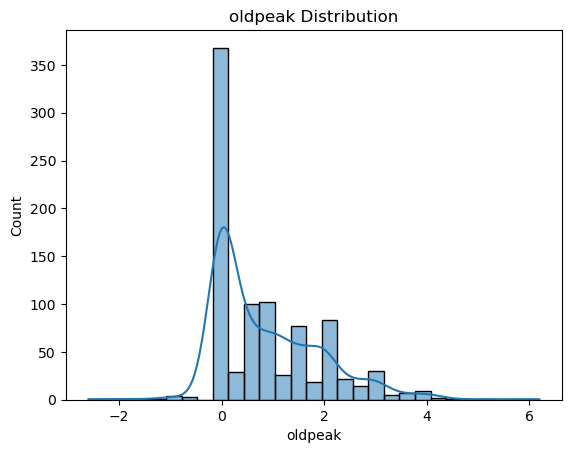

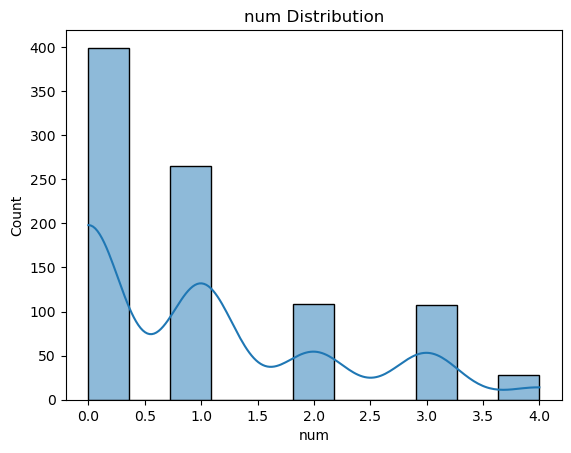

In [57]:
for col in num_col:
    sns.histplot(data[col],kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

In [58]:
for col in num_col:
    print(f'{col} Skewness :', data[col].skew())

age Skewness : -0.13679653817221868
trestbps Skewness : 0.3536499733817675
chol Skewness : -0.564765692042219
fbs Skewness : 1.4734847075995843
thalch Skewness : -0.21955477484333802
oldpeak Skewness : 1.1169442916724792
num Skewness : 0.9514085875909324


#### - Most features like age, trestbps, and thalch are approximately normally distributed. 
#### - However, oldpeak is highly right-skewed and may require transformation, while chol and num show moderate skewness.

#### 2. Boxplot :

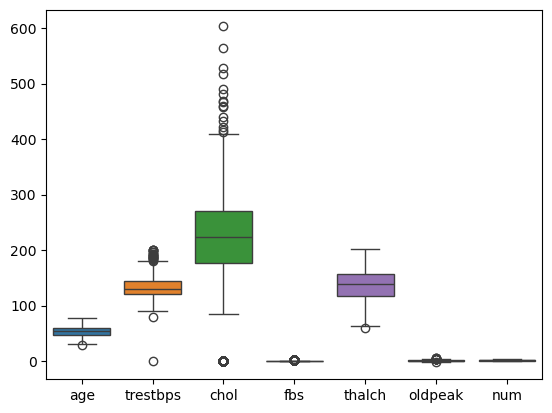

In [59]:
sns.boxplot(data)
plt.show()

#### According to boxplot outliers are present in the data. So will replace the outliers with upper bound and lower bounds

In [60]:
for col in num_col:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR
    outliers = data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    print(f'{col} outliers :',outliers.shape[0])

age outliers : 1
trestbps outliers : 22
chol outliers : 187
fbs outliers : 185
thalch outliers : 1
oldpeak outliers : 16
num outliers : 0


In [61]:
for col in num_col:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5*IQR
    data[col] = data[col].clip(lower_bound,upper_bound)

#### Lets Check After replacing values:

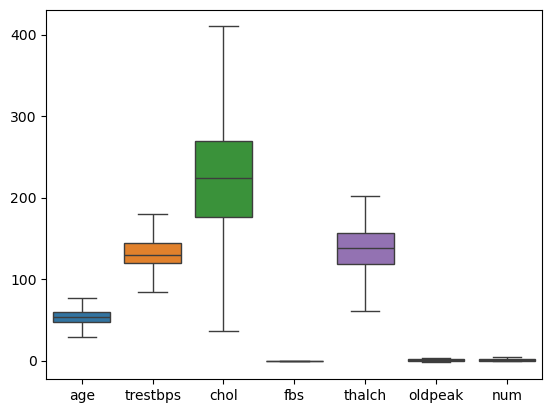

In [62]:
sns.boxplot(data)
plt.show()

#### Corelation Heatmap :

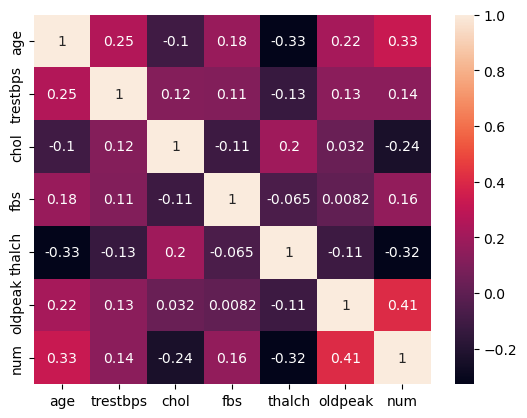

In [63]:
corr = num_col.corr()
sns.heatmap(corr,annot=True)
plt.show()

### 3. Feature Engineering:

#### Encoding of Categorical columns:

In [64]:
cat_cols = data.select_dtypes(include=['object']).columns

In [65]:
cat_cols

Index(['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [66]:
for col in cat_cols :
    print(col, data[col].apply(type).unique())
    data[col] = data[col].astype(str)

sex [<class 'str'>]
cp [<class 'str'>]
restecg [<class 'str'>]
exang [<class 'bool'> <class 'str'>]
slope [<class 'str'>]
thal [<class 'str'>]


In [67]:
from sklearn.preprocessing import LabelEncoder

In [68]:
le = LabelEncoder()
for col in cat_cols:
    data[col]= le.fit_transform(data[col])
    

In [111]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,1,3,145,233.0,0,0,150,1,2.3,0,0,0
1,41.0,1,1,135,203.0,0,1,132,1,0.0,1,0,0
2,57.0,1,0,140,192.0,0,1,148,1,0.4,1,0,0
3,52.0,1,3,118,186.0,0,0,190,1,0.0,1,0,0
4,57.0,1,0,110,201.0,0,1,126,3,1.5,1,0,0


#### Feature scaling was not applied as Decision Tree models are not sensitive to feature scaling since they split data based on feature thresholds rather than distance measures.”

#### 4. Decision Tree Classification:

#### Split the data

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X = data.drop('num',axis=1)
y = data['num']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((726, 12), (182, 12), (726,), (182,))

#### Build the Model :

In [73]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
dtc = DecisionTreeClassifier(max_depth=6,criterion='entropy')
dtc.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6)

#### Evaluate the model on training data :

In [89]:
from sklearn.metrics import classification_report,confusion_matrix

In [90]:
ypred_train = dtc.predict(X_train)

In [91]:
cm = confusion_matrix(y_train,ypred_train)
cm

array([[275,  27,   4,   4,   0],
       [ 65, 138,   7,   7,   0],
       [ 16,  26,  35,  10,   0],
       [ 14,  34,   4,  35,   3],
       [  2,   8,   2,   0,  10]])

In [92]:
print(classification_report(y_train,ypred_train))

              precision    recall  f1-score   support

           0       0.74      0.89      0.81       310
           1       0.59      0.64      0.61       217
           2       0.67      0.40      0.50        87
           3       0.62      0.39      0.48        90
           4       0.77      0.45      0.57        22

    accuracy                           0.68       726
   macro avg       0.68      0.55      0.59       726
weighted avg       0.67      0.68      0.66       726



In [93]:
ypred_test = dtc.predict(X_test)

In [94]:
cm = confusion_matrix(y_test,ypred_test)
cm

array([[75,  9,  3,  1,  1],
       [23, 18,  3,  4,  0],
       [ 7, 12,  2,  1,  0],
       [ 5, 10,  2,  0,  0],
       [ 1,  3,  1,  1,  0]])

In [95]:
print(classification_report(y_test,ypred_test))

              precision    recall  f1-score   support

           0       0.68      0.84      0.75        89
           1       0.35      0.38      0.36        48
           2       0.18      0.09      0.12        22
           3       0.00      0.00      0.00        17
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.24      0.26      0.25       182
weighted avg       0.44      0.52      0.48       182



### 5. Hyperparameter Tuning:

#### - Hyperparameter tuning is the process of optimizing the parameters of a model that are set before training.
#### - In Decision Tree Classification, parameters such as max_depth, min_samples_split, and criterion control the complexity of the model. 
#### - Proper tuning helps in improving model performance and preventing overfitting or underfitting.

#### Hyperparameters Used

##### max_depth → Controls depth of tree
##### min_samples_split → Minimum samples required to split
##### criterion → Split quality (gini or entropy)

#### Implementation :

In [82]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dtc = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(dtc, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


#### Result :

#### Model Evaluation After Tuning :

In [83]:
from sklearn.metrics import accuracy_score
y_pred = best_model.predict(X_test)
print("Accuracy after tuning:", accuracy_score(y_test, y_pred))

Accuracy after tuning: 0.5714285714285714


### 6. Model Evaluation and Analysis:

#### Visualizarion of trees

In [98]:
from sklearn.tree import plot_tree

In [99]:
cnames = list(map(str, y.unique()))
cnames

['0', '1', '2', '3', '4']

In [100]:
fnames = X.columns
fnames

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal'],
      dtype='object')

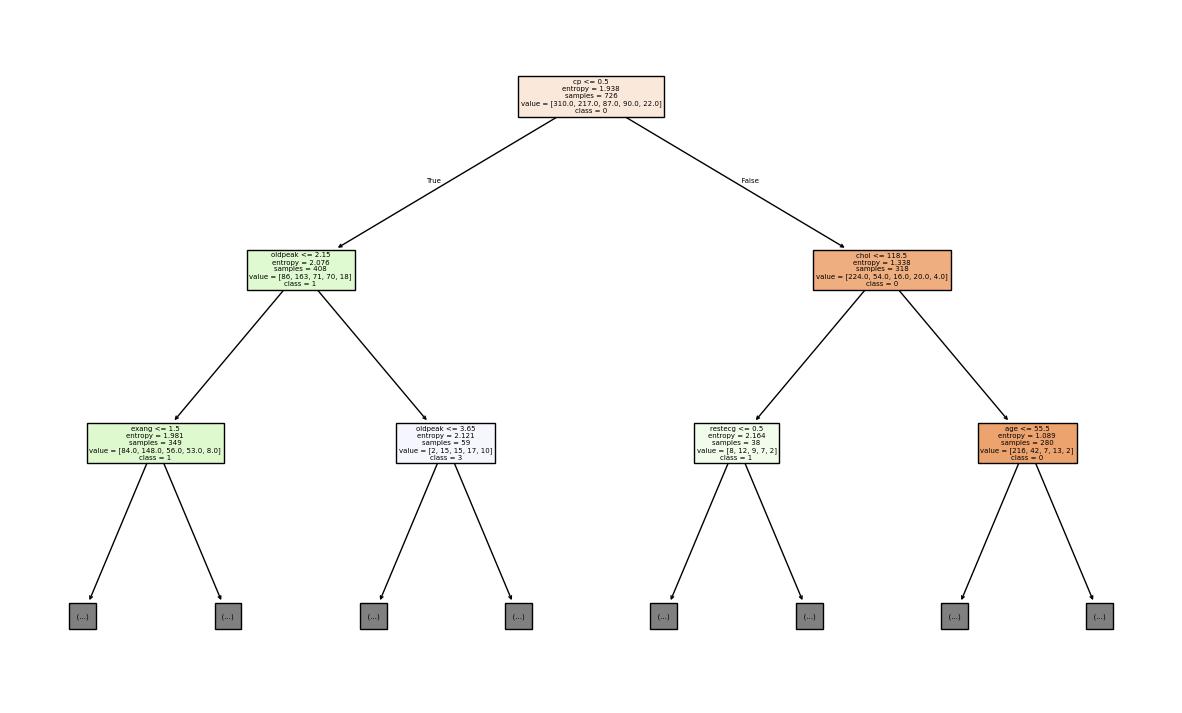

In [110]:
plt.figure(figsize=(15,9))
plot_tree(dtc,class_names=cnames,feature_names=fnames,filled=True,max_depth=2)
plt.show()

#### The performance of the Decision Tree Classifier was evaluated using various metrics such as Accuracy, Precision, Recall, and F1-score.

#### The model achieved an accuracy of 0.5714285714285714 on the test dataset, indicating that it performs well in predicting the target variable.

### Conclusion :

#### - The Decision Tree model performs effectively on the dataset and provides interpretable results.
#### - Hyperparameter tuning improved the model performance and reduced overfitting.
#### - The visualization of the tree helps in understanding the decision rules, and feature importance highlights the key factors affecting the prediction of heart disease.

#### Interview Questions:

#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

#### - Common hyperparameters like max_depth, min_samples_split, and criterion control tree complexity. 
#### - Tuning them helps prevent overfitting and improves model performance.”

#### 2. What is the difference between the Label encoding and One-hot encoding?

#### -Label Encoding assigns numerical values to categories but introduces an artificial order, 
#### whereas One-Hot Encoding creates binary columns and avoids any ordinal relationship.”